# Housing-equivalent value of classifier improvement

This study quantifies how many annual housing placements a classifier improvement is equivalent to.

The primary outcome is

$$
P_{\mathrm{ab},C}
=
P(\text{abandon} \mid \text{true chronic}).
$$

For a poorer classifier used with annual housing supply $$H_{\mathrm{ref}}$$, we find the minimum housing supply required by a better classifier to achieve the same or lower chronic abandonment probability:

$$
H_{\mathrm{req}}
=
\min\left\{
H:
P_{\mathrm{ab},C}(\text{better classifier},H)
\leq
P_{\mathrm{ab},C}(\text{poorer classifier},H_{\mathrm{ref}})
\right\}.
$$

The housing-equivalent value of the classifier improvement is then

$$
E_H
=
H_{\mathrm{ref}}-H_{\mathrm{req}}.
$$

A positive value means that the better classifier achieves the reference outcome with fewer annual housing placements.

The notebook has three parts:

1. a full classifier-quality and housing-supply surface
2. housing-equivalent values across different levels of scarcity
3. separate effects of reducing chronic false negatives and transient false positives


In [13]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "gi_gi_n_gi_multiclass").exists():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gi_gi_n_gi_multiclass.core.engine_multi import run_sim_multi
from gi_gi_n_gi_multiclass.core.types_multi import CustomerClass, MultiSimConfig
from gi_gi_n_gi_multiclass.dists.common import Deterministic, LogNormal
from gi_gi_n_gi_multiclass.labelling import ConfusionMatrixClassifier
from gi_gi_n_gi_multiclass.metrics.class_metrics import (
    abandonment_probability_by_true_class,
)
from gi_gi_n_gi_multiclass.outputs.schemas import customers_to_dataframe
from gi_gi_n_gi_multiclass.policies.priority_fcfs import PriorityFCFS


## Housing-system configuration

Each annual intake contains 200 people:

$$
80 \text{ true chronic},
\qquad
120 \text{ true non-chronic}.
$$

Cohorts arrive annually at

$$
t=0,1,\ldots,5.
$$

Housing is released annually from year 1 onward. A person arriving at time $$t$$ becomes eligible at time

$$
t+1.
$$

Housing is consumable capacity: once a unit is assigned, it does not return to the system.

The policy is fixed throughout:

- assigned chronic first
- FCFS within assigned class

This isolates the effects of classifier errors and housing supply.


In [14]:
ANNUAL_CHRONIC = 80
ANNUAL_TRANSIENT = 120
BATCH_COUNTS = [ANNUAL_CHRONIC, ANNUAL_TRANSIENT]

FIRST_BATCH_TIME = 0.0
LAST_BATCH_TIME = 5.0
BATCH_INTERVAL = 1.0

FIRST_HOUSING_RELEASE = 1.0
HOUSING_RELEASE_INTERVAL = 1.0
ELIGIBILITY_DELAY = 1.0

RUN_TIME = 50.0
SEEDS = [1, 2, 3]

housing_supply_grid = np.arange(50, 151, 5)
quality_grid = np.arange(0.50, 0.901, 0.025)

fixed_policy = PriorityFCFS(priority_order=[0, 1])


In [15]:
true_chronic = CustomerClass(
    name="chronic",
    interarrival=Deterministic(1.0),   # ignored in housing mode
    service=Deterministic(0.0),        # allocation is instantaneous
    patience=LogNormal(meanlog=1.10, sdlog=0.85),
)

true_transient = CustomerClass(
    name="transient",
    interarrival=Deterministic(1.0),   # ignored in housing mode
    service=Deterministic(0.0),
    patience=LogNormal(meanlog=0.90, sdlog=0.95),
)

classes = [true_chronic, true_transient]


## Classifier definitions

Rows of the confusion matrix are true classes and columns are assigned classes:

$$
\begin{bmatrix}
P(\widehat C=C\mid C=C) &
P(\widehat C=T\mid C=C)
\\
P(\widehat C=C\mid C=T) &
P(\widehat C=T\mid C=T)
\end{bmatrix}.
$$

Define chronic sensitivity and transient specificity by

$$
s=P(\widehat C=C\mid C=C),
\qquad
r=P(\widehat C=T\mid C=T).
$$

The first two studies use an asymmetric one-parameter quality path:

$$
s(q)=q+0.05,
\qquad
r(q)=q-0.05.
$$

Thus chronic false negatives and transient false positives remain different as classifier quality changes.


In [16]:
def classifier_from_rates(
    sensitivity: float,
    specificity: float,
) -> ConfusionMatrixClassifier:
    if not (0.0 <= sensitivity <= 1.0):
        raise ValueError("sensitivity must lie in [0, 1]")
    if not (0.0 <= specificity <= 1.0):
        raise ValueError("specificity must lie in [0, 1]")

    matrix = np.array([
        [sensitivity, 1.0 - sensitivity],
        [1.0 - specificity, specificity],
    ])
    return ConfusionMatrixClassifier(matrix)


def classifier_from_quality(quality: float) -> ConfusionMatrixClassifier:
    return classifier_from_rates(
        sensitivity=quality + 0.05,
        specificity=quality - 0.05,
    )


## Simulation runner

Every reported parameter point is averaged over the same set of random seeds.

Common random seed values reduce unnecessary variation when comparing nearby classifier and housing settings.


In [17]:
def run_housing_case(
    classifier: ConfusionMatrixClassifier,
    annual_housing_supply: int,
    seed: int,
    scenario: str,
    classifier_quality: float = np.nan,
    sensitivity: float = np.nan,
    specificity: float = np.nan,
) -> dict:
    cfg = MultiSimConfig(
        n_servers=int(annual_housing_supply),
        classes=classes,
        classifier=classifier,
        policy=fixed_policy,
        seed=int(seed),
        warmup_time=0.0,
        run_time=RUN_TIME,
        housing_mode=True,
        batch_arrival_counts=BATCH_COUNTS,
        batch_interval=BATCH_INTERVAL,
        first_batch_time=FIRST_BATCH_TIME,
        last_batch_time=LAST_BATCH_TIME,
        housing_release_interval=HOUSING_RELEASE_INTERVAL,
        first_housing_release=FIRST_HOUSING_RELEASE,
        initial_housing_stock=0,
        eligibility_delay=ELIGIBILITY_DELAY,
        collect_event_log=False,
    )

    result = run_sim_multi(cfg)
    customers = customers_to_dataframe(result)

    chronic = customers[customers["true_class_id"] == 0]
    transient = customers[customers["true_class_id"] == 1]

    return {
        "scenario": scenario,
        "classifier_quality": classifier_quality,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "annual_housing_supply": int(annual_housing_supply),
        "seed": int(seed),
        "true_chronic_abandon_prob": abandonment_probability_by_true_class(
            result, 0
        ),
        "true_transient_abandon_prob": abandonment_probability_by_true_class(
            result, 1
        ),
        "true_chronic_housed_prob": float(
            (chronic["outcome"] == "SERVED").mean()
        ),
        "true_transient_housed_prob": float(
            (transient["outcome"] == "SERVED").mean()
        ),
        "unresolved_prob": float(
            (customers["outcome"] == "IN_SYSTEM_END").mean()
        ),
    }


# Study 1: classifier quality and housing supply

This study estimates

$$
P_{\mathrm{ab},C}(q,H)
$$

over the full classifier-quality and housing-supply grid.


In [18]:
quality_rows = []

for annual_housing_supply in housing_supply_grid:
    for quality in quality_grid:
        sensitivity = quality + 0.05
        specificity = quality - 0.05
        classifier = classifier_from_quality(quality)

        for seed in SEEDS:
            quality_rows.append(
                run_housing_case(
                    classifier=classifier,
                    annual_housing_supply=annual_housing_supply,
                    seed=seed,
                    scenario="asymmetric_quality_path",
                    classifier_quality=quality,
                    sensitivity=sensitivity,
                    specificity=specificity,
                )
            )

quality_results = pd.DataFrame(quality_rows)

quality_summary = (
    quality_results
    .groupby(
        [
            "classifier_quality",
            "sensitivity",
            "specificity",
            "annual_housing_supply",
        ],
        as_index=False,
    )
    .agg(
        true_chronic_abandon_prob=(
            "true_chronic_abandon_prob", "mean"
        ),
        true_chronic_abandon_se=(
            "true_chronic_abandon_prob",
            lambda x: x.std(ddof=1) / np.sqrt(len(x)),
        ),
        true_transient_abandon_prob=(
            "true_transient_abandon_prob", "mean"
        ),
        unresolved_prob=("unresolved_prob", "mean"),
    )
)

quality_summary.head()


,classifier_quality,sensitivity,specificity,annual_housing_supply,true_chronic_abandon_prob,true_chronic_abandon_se,true_transient_abandon_prob,unresolved_prob
0,0.5,0.55,0.45,50,0.527778,0.004554,0.642130,0.0
1,0.5,0.55,0.45,55,0.501389,0.010781,0.617130,0.0
2,0.5,0.55,0.45,60,0.486806,0.010848,0.584722,0.0
3,0.5,0.55,0.45,65,0.468750,0.006697,0.555556,0.0
4,0.5,0.55,0.45,70,0.431250,0.004167,0.540741,0.0


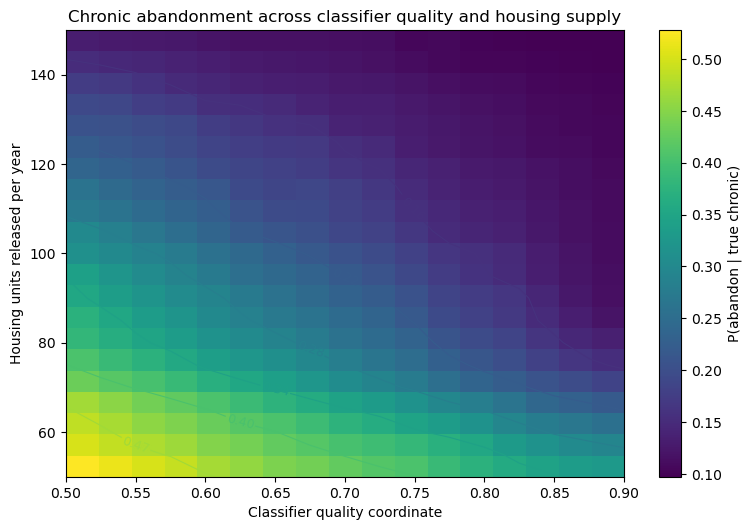

In [19]:
pivot = (
    quality_summary
    .pivot(
        index="annual_housing_supply",
        columns="classifier_quality",
        values="true_chronic_abandon_prob",
    )
    .sort_index()
)

x = pivot.columns.to_numpy(dtype=float)
y = pivot.index.to_numpy(dtype=float)
z = pivot.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(9.0, 5.8))

image = ax.imshow(
    z,
    origin="lower",
    aspect="auto",
    extent=[x.min(), x.max(), y.min(), y.max()],
    interpolation="none",
)

contours = ax.contour(
    x,
    y,
    z,
    levels=np.linspace(np.nanmin(z), np.nanmax(z), 8),
    linewidths=0.8,
)
ax.clabel(contours, inline=True, fontsize=9, fmt="%.2f")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label("P(abandon | true chronic)")

ax.set_xlabel("Classifier quality coordinate")
ax.set_ylabel("Housing units released per year")
ax.set_title("Chronic abandonment across classifier quality and housing supply")

plt.show()


# Study 2: housing-equivalent value across scarcity

For each reference supply $$H_{\mathrm{ref}}$$ and classifier improvement from $$q_0$$ to $$q_1$$, calculate the housing supply required under the better classifier to match the poorer-classifier outcome.

The interpolation below first imposes the expected non-increasing relationship between abandonment and housing supply. This prevents small Monte Carlo fluctuations from producing artificial reversals.

The resulting equivalence is

$$
E_H(q_0\rightarrow q_1;H_{\mathrm{ref}})
=
H_{\mathrm{ref}}
-
H_{\mathrm{req}}.
$$

The dependence of $$E_H$$ on $$H_{\mathrm{ref}}$$ shows how the value of classifier improvement changes with scarcity.


In [20]:
def monotone_supply_curve(
    summary_df: pd.DataFrame,
    selector: dict,
    outcome_col: str = "true_chronic_abandon_prob",
) -> pd.DataFrame:
    mask = np.ones(len(summary_df), dtype=bool)

    for column, value in selector.items():
        mask &= np.isclose(
            summary_df[column].to_numpy(dtype=float),
            float(value),
        )

    curve = (
        summary_df.loc[mask, ["annual_housing_supply", outcome_col]]
        .sort_values("annual_housing_supply")
        .drop_duplicates("annual_housing_supply")
        .reset_index(drop=True)
    )

    if curve.empty:
        raise ValueError(f"No curve found for selector {selector}")

    # More housing should not increase abandonment.
    curve["outcome_monotone"] = np.minimum.accumulate(
        curve[outcome_col].to_numpy(dtype=float)
    )
    return curve


def required_supply_for_target(
    curve: pd.DataFrame,
    target_outcome: float,
) -> float:
    supply = curve["annual_housing_supply"].to_numpy(dtype=float)
    outcome = curve["outcome_monotone"].to_numpy(dtype=float)

    # The target is already met at the smallest simulated supply.
    if outcome[0] <= target_outcome:
        return float(supply[0])

    # The target is not reached anywhere on the simulated supply grid.
    if outcome[-1] > target_outcome:
        return np.nan

    # Invert the non-increasing outcome curve.
    return float(
        np.interp(
            target_outcome,
            outcome[::-1],
            supply[::-1],
        )
    )


def housing_equivalent_for_quality_improvement(
    summary_df: pd.DataFrame,
    poorer_quality: float,
    better_quality: float,
    reference_supplies,
) -> pd.DataFrame:
    poorer_curve = monotone_supply_curve(
        summary_df,
        {"classifier_quality": poorer_quality},
    )
    better_curve = monotone_supply_curve(
        summary_df,
        {"classifier_quality": better_quality},
    )

    poorer_supply = poorer_curve[
        "annual_housing_supply"
    ].to_numpy(dtype=float)
    poorer_outcome = poorer_curve[
        "outcome_monotone"
    ].to_numpy(dtype=float)

    rows = []

    for reference_supply in reference_supplies:
        target = float(
            np.interp(
                reference_supply,
                poorer_supply,
                poorer_outcome,
            )
        )
        required_supply = required_supply_for_target(
            better_curve,
            target,
        )

        rows.append({
            "poorer_quality": poorer_quality,
            "better_quality": better_quality,
            "reference_supply": float(reference_supply),
            "reference_outcome": target,
            "required_supply_better_classifier": required_supply,
            "housing_equivalent": (
                float(reference_supply) - required_supply
                if np.isfinite(required_supply)
                else np.nan
            ),
        })

    return pd.DataFrame(rows)


In [21]:
quality_improvements = [
    (0.60, 0.70),
    (0.60, 0.80),
    (0.60, 0.90),
    (0.70, 0.80),
    (0.70, 0.90),
    (0.80, 0.90),
]

reference_supplies = housing_supply_grid

equivalence_tables = []

for poorer_quality, better_quality in quality_improvements:
    equivalence_tables.append(
        housing_equivalent_for_quality_improvement(
            summary_df=quality_summary,
            poorer_quality=poorer_quality,
            better_quality=better_quality,
            reference_supplies=reference_supplies,
        )
    )

quality_equivalence = pd.concat(
    equivalence_tables,
    ignore_index=True,
)

quality_equivalence.head()


,poorer_quality,better_quality,reference_supply,reference_outcome,required_supply_better_classifier,housing_equivalent
0,0.6,0.7,50.0,0.469444,50.000000,0.000000
1,0.6,0.7,55.0,0.448611,50.000000,5.000000
2,0.6,0.7,60.0,0.429861,50.000000,10.000000
3,0.6,0.7,65.0,0.406250,54.218750,10.781250
4,0.6,0.7,70.0,0.368750,61.162791,8.837209


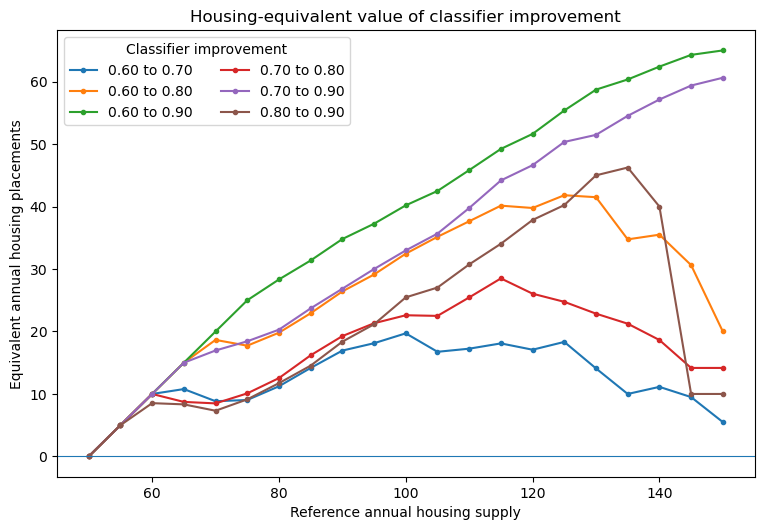

In [22]:
fig, ax = plt.subplots(figsize=(9.0, 5.8))

for (poorer_quality, better_quality), group in quality_equivalence.groupby(
    ["poorer_quality", "better_quality"]
):
    group = group.sort_values("reference_supply")
    ax.plot(
        group["reference_supply"],
        group["housing_equivalent"],
        marker="o",
        markersize=3,
        label=f"{poorer_quality:.2f} to {better_quality:.2f}",
    )

ax.axhline(0.0, linewidth=0.8)
ax.set_xlabel("Reference annual housing supply")
ax.set_ylabel("Equivalent annual housing placements")
ax.set_title("Housing-equivalent value of classifier improvement")
ax.legend(title="Classifier improvement", ncol=2)
plt.show()


## Reading the equivalence curves

A value of

$$
E_H=30
$$

at reference supply $$H_{\mathrm{ref}}=100$$ means that the better classifier reaches the poorer classifier's chronic-abandonment outcome with approximately

$$
100-30=70
$$

annual housing placements.

The shape of each curve matters:

- larger equivalence under low supply means classifier quality is especially valuable under severe scarcity
- larger equivalence under high supply means classification remains valuable even when housing is relatively abundant
- equivalence approaching zero means additional classifier improvement has little remaining effect at that supply level


In [23]:
selected_reference_supplies = [60, 80, 100, 120, 140]

quality_equivalence_table = (
    quality_equivalence[
        quality_equivalence["reference_supply"].isin(
            selected_reference_supplies
        )
    ]
    .pivot_table(
        index=["poorer_quality", "better_quality"],
        columns="reference_supply",
        values="housing_equivalent",
    )
    .round(1)
)

quality_equivalence_table


reference_supply               60.0   80.0   100.0  120.0  140.0
poorer_quality better_quality                                   
0.6            0.7              10.0   11.2   19.7   17.1   11.1
               0.8              10.0   19.8   32.5   39.8   35.5
               0.9              10.0   28.3   40.2   51.6   62.4
0.7            0.8              10.0   12.5   22.6   26.1   18.6
               0.9              10.0   20.3   33.0   46.6   57.1
0.8            0.9               8.5   11.7   25.5   37.9   40.0

# Study 3: false negatives versus false positives

Overall or balanced accuracy can conceal which type of error has improved.

For the chronic-abandonment objective, the two error types act differently:

- a chronic false negative places a truly chronic person in the lower-priority assigned-transient queue
- a transient false positive places a truly transient person in the higher-priority assigned-chronic queue

We compare four classifier scenarios:

1. baseline classifier
2. reduced chronic false-negative rate only
3. reduced transient false-positive rate only
4. both error rates improved

The policy and housing system remain fixed.


In [24]:
error_scenarios = {
    "baseline": {
        "sensitivity": 0.65,
        "specificity": 0.65,
    },
    "reduce_false_negatives": {
        "sensitivity": 0.85,
        "specificity": 0.65,
    },
    "reduce_false_positives": {
        "sensitivity": 0.65,
        "specificity": 0.85,
    },
    "improve_both": {
        "sensitivity": 0.85,
        "specificity": 0.85,
    },
}

error_rows = []

for scenario, rates in error_scenarios.items():
    classifier = classifier_from_rates(
        sensitivity=rates["sensitivity"],
        specificity=rates["specificity"],
    )

    for annual_housing_supply in housing_supply_grid:
        for seed in SEEDS:
            error_rows.append(
                run_housing_case(
                    classifier=classifier,
                    annual_housing_supply=annual_housing_supply,
                    seed=seed,
                    scenario=scenario,
                    sensitivity=rates["sensitivity"],
                    specificity=rates["specificity"],
                )
            )

error_results = pd.DataFrame(error_rows)

error_summary = (
    error_results
    .groupby(
        [
            "scenario",
            "sensitivity",
            "specificity",
            "annual_housing_supply",
        ],
        as_index=False,
    )
    .agg(
        true_chronic_abandon_prob=(
            "true_chronic_abandon_prob", "mean"
        ),
        true_chronic_abandon_se=(
            "true_chronic_abandon_prob",
            lambda x: x.std(ddof=1) / np.sqrt(len(x)),
        ),
        true_transient_abandon_prob=(
            "true_transient_abandon_prob", "mean"
        ),
        unresolved_prob=("unresolved_prob", "mean"),
    )
)

error_summary.head()


,scenario,sensitivity,specificity,annual_housing_supply,true_chronic_abandon_prob,true_chronic_abandon_se,true_transient_abandon_prob,unresolved_prob
0,baseline,0.65,0.65,50,0.447917,0.006250,0.696296,0.0
1,baseline,0.65,0.65,55,0.424306,0.005008,0.667593,0.0
2,baseline,0.65,0.65,60,0.397222,0.005424,0.643056,0.0
3,baseline,0.65,0.65,65,0.359028,0.002504,0.624074,0.0
4,baseline,0.65,0.65,70,0.331944,0.005933,0.605093,0.0


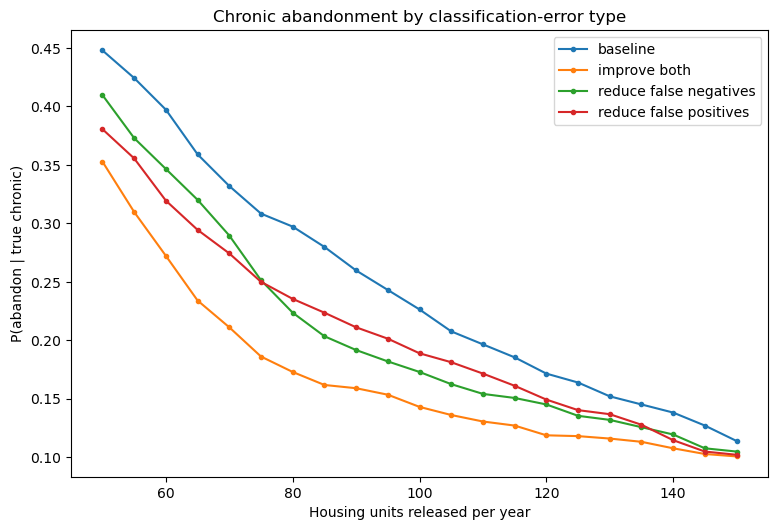

In [25]:
fig, ax = plt.subplots(figsize=(9.0, 5.8))

for scenario, group in error_summary.groupby("scenario"):
    group = group.sort_values("annual_housing_supply")
    ax.plot(
        group["annual_housing_supply"],
        group["true_chronic_abandon_prob"],
        marker="o",
        markersize=3,
        label=scenario.replace("_", " "),
    )

ax.set_xlabel("Housing units released per year")
ax.set_ylabel("P(abandon | true chronic)")
ax.set_title("Chronic abandonment by classification-error type")
ax.legend()
plt.show()


## Housing-equivalent value by error type

The baseline classifier is used as the reference.

For each reference housing supply, we calculate how many fewer annual placements are required after:

- reducing chronic false negatives only
- reducing transient false positives only
- reducing both error types

This directly compares the operational value of improving the two rows of the confusion matrix.


In [26]:
def housing_equivalent_between_scenarios(
    summary_df: pd.DataFrame,
    baseline_scenario: str,
    improved_scenario: str,
    reference_supplies,
) -> pd.DataFrame:
    baseline_curve = (
        summary_df[
            summary_df["scenario"] == baseline_scenario
        ][
            ["annual_housing_supply", "true_chronic_abandon_prob"]
        ]
        .sort_values("annual_housing_supply")
        .reset_index(drop=True)
    )
    improved_curve = (
        summary_df[
            summary_df["scenario"] == improved_scenario
        ][
            ["annual_housing_supply", "true_chronic_abandon_prob"]
        ]
        .sort_values("annual_housing_supply")
        .reset_index(drop=True)
    )

    baseline_curve["outcome_monotone"] = np.minimum.accumulate(
        baseline_curve[
            "true_chronic_abandon_prob"
        ].to_numpy(dtype=float)
    )
    improved_curve["outcome_monotone"] = np.minimum.accumulate(
        improved_curve[
            "true_chronic_abandon_prob"
        ].to_numpy(dtype=float)
    )

    baseline_supply = baseline_curve[
        "annual_housing_supply"
    ].to_numpy(dtype=float)
    baseline_outcome = baseline_curve[
        "outcome_monotone"
    ].to_numpy(dtype=float)

    rows = []

    for reference_supply in reference_supplies:
        target = float(
            np.interp(
                reference_supply,
                baseline_supply,
                baseline_outcome,
            )
        )
        required_supply = required_supply_for_target(
            improved_curve,
            target,
        )

        rows.append({
            "improvement": improved_scenario,
            "reference_supply": float(reference_supply),
            "reference_outcome": target,
            "required_supply_improved_classifier": required_supply,
            "housing_equivalent": (
                float(reference_supply) - required_supply
                if np.isfinite(required_supply)
                else np.nan
            ),
        })

    return pd.DataFrame(rows)


error_equivalence = pd.concat(
    [
        housing_equivalent_between_scenarios(
            summary_df=error_summary,
            baseline_scenario="baseline",
            improved_scenario=improved_scenario,
            reference_supplies=housing_supply_grid,
        )
        for improved_scenario in [
            "reduce_false_negatives",
            "reduce_false_positives",
            "improve_both",
        ]
    ],
    ignore_index=True,
)

error_equivalence.head()


,improvement,reference_supply,reference_outcome,required_supply_improved_classifier,housing_equivalent
0,reduce_false_negatives,50.0,0.447917,50.000000,0.000000
1,reduce_false_negatives,55.0,0.424306,50.000000,5.000000
2,reduce_false_negatives,60.0,0.397222,51.698113,8.301887
3,reduce_false_negatives,65.0,0.359028,57.631579,7.368421
4,reduce_false_negatives,70.0,0.331944,62.763158,7.236842


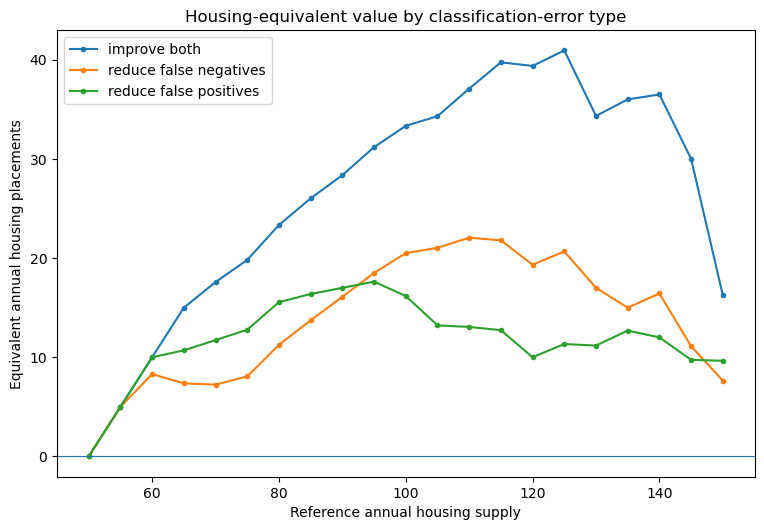

In [27]:
fig, ax = plt.subplots(figsize=(9.0, 5.8))

for improvement, group in error_equivalence.groupby("improvement"):
    group = group.sort_values("reference_supply")
    ax.plot(
        group["reference_supply"],
        group["housing_equivalent"],
        marker="o",
        markersize=3,
        label=improvement.replace("_", " "),
    )

ax.axhline(0.0, linewidth=0.8)
ax.set_xlabel("Reference annual housing supply")
ax.set_ylabel("Equivalent annual housing placements")
ax.set_title("Housing-equivalent value by classification-error type")
ax.legend()
plt.show()


In [28]:
error_equivalence_table = (
    error_equivalence[
        error_equivalence["reference_supply"].isin(
            selected_reference_supplies
        )
    ]
    .pivot_table(
        index="improvement",
        columns="reference_supply",
        values="housing_equivalent",
    )
    .round(1)
)

error_equivalence_table


reference_supply,60.0,80.0,100.0,120.0,140.0
improvement,,,,,
improve_both,10.0,23.3,33.3,39.4,36.5
reduce_false_negatives,8.3,11.2,20.5,19.3,16.4
reduce_false_positives,10.0,15.6,16.2,10.0,12.0


# Diagnostics and interpretation

Before interpreting the equivalence values, check:

1. unresolved probability is zero or negligible
2. chronic abandonment is approximately non-increasing in housing supply
3. chronic abandonment improves in the expected direction under the classifier changes
4. equivalence values are not determined entirely by the edges of the housing grid

A value equal to the maximum possible saving on the simulated grid should be interpreted as a lower bound. For example, if the smallest simulated supply is 50 and the reference supply is 100, a reported equivalence of 50 may mean that the better classifier would require fewer than 50 placements, but that region was not simulated.

The main comparisons are:

$$
E_H(q_0\rightarrow q_1;H_{\mathrm{ref}})
$$

for classifier-quality improvements, and

$$
E_H(\text{reduce false negatives};H_{\mathrm{ref}})
$$

versus

$$
E_H(\text{reduce false positives};H_{\mathrm{ref}})
$$

for error-type improvements.

These results quantify both:

- how classifier improvement substitutes for housing supply
- whether that substitution is strongest under severe or mild scarcity
- which classification error is most costly for truly chronic people


In [29]:
diagnostics = pd.DataFrame({
    "maximum_unresolved_quality_study": [
        quality_summary["unresolved_prob"].max()
    ],
    "maximum_unresolved_error_study": [
        error_summary["unresolved_prob"].max()
    ],
    "minimum_quality_equivalence": [
        quality_equivalence["housing_equivalent"].min()
    ],
    "maximum_quality_equivalence": [
        quality_equivalence["housing_equivalent"].max()
    ],
    "minimum_error_equivalence": [
        error_equivalence["housing_equivalent"].min()
    ],
    "maximum_error_equivalence": [
        error_equivalence["housing_equivalent"].max()
    ],
})

diagnostics


,maximum_unresolved_quality_study,maximum_unresolved_error_study,minimum_quality_equivalence,maximum_quality_equivalence,minimum_error_equivalence,maximum_error_equivalence
0,0.0,0.0,0.0,65.0,0.0,40.9375


## Optional exports

The raw and summarized results can be saved for later plotting or statistical analysis.


In [30]:
OUTPUT_DIR = Path("housing_equivalent_results")
OUTPUT_DIR.mkdir(exist_ok=True)

quality_results.to_csv(
    OUTPUT_DIR / "quality_raw.csv",
    index=False,
)
quality_summary.to_csv(
    OUTPUT_DIR / "quality_summary.csv",
    index=False,
)
quality_equivalence.to_csv(
    OUTPUT_DIR / "quality_housing_equivalence.csv",
    index=False,
)

error_results.to_csv(
    OUTPUT_DIR / "error_type_raw.csv",
    index=False,
)
error_summary.to_csv(
    OUTPUT_DIR / "error_type_summary.csv",
    index=False,
)
error_equivalence.to_csv(
    OUTPUT_DIR / "error_type_housing_equivalence.csv",
    index=False,
)

print(f"Saved results to {OUTPUT_DIR.resolve()}")


Saved results to /Users/jste924/Documents/Python scripts/RA work/queue_sims_heterogenous/04_homeless_studies/housing_equivalent_results


## Main result

The study shows the intended substitution clearly:

$$
\text{better classification}
\quad \Longleftrightarrow \quad
\text{fewer annual housing placements}
$$

for the same chronic-abandonment outcome.

The effect is not constant. Its housing-equivalent value depends strongly on:

- the starting classifier quality
- the reference housing supply

For example, improving classifier quality from $$0.60$$ to $$0.90$$ is equivalent to approximately:

$$
28
$$

annual housing placements at a reference supply of 80,

$$
40
$$

placements at a reference supply of 100,

$$
52
$$

placements at a reference supply of 120,

and

$$
62
$$

placements at a reference supply of 140.

So, within this model, the value of the classifier improvement generally becomes larger as the reference system has more housing available.

## Why the equivalence increases with supply

At very low supply, nearly everyone is exposed to substantial abandonment risk. Even a better classifier cannot create housing that does not exist.

At intermediate and higher supply, targeting matters more. There are enough units for allocation decisions to determine which population benefits. A better classifier directs a larger fraction of those units towards truly chronic people.

This produces the pattern

$$
\text{extreme scarcity}
\Rightarrow
\text{capacity dominates},
$$

whereas

$$
\text{moderate scarcity}
\Rightarrow
\text{classification has greater operational value}.
$$

This is one of the most interesting findings in the results.

## The relationship is not simply linear

The housing-equivalent value is not proportional to the classifier improvement.

At reference supply 120:

| Classifier improvement | Equivalent annual placements |
|---|---:|
| $$0.60 \rightarrow 0.70$$ | 17.1 |
| $$0.60 \rightarrow 0.80$$ | 39.8 |
| $$0.60 \rightarrow 0.90$$ | 51.6 |
| $$0.70 \rightarrow 0.80$$ | 26.1 |
| $$0.70 \rightarrow 0.90$$ | 46.6 |
| $$0.80 \rightarrow 0.90$$ | 37.9 |

The final improvement from $$0.80$$ to $$0.90$$ is still valuable. There is no clear evidence here that classifier improvements become negligible at high accuracy.

Some irregularity is expected because the equivalence is obtained by inverting simulated outcome curves using only three seeds.

## Error type matters substantially

The separate false-negative and false-positive study is especially interesting.

The baseline classifier has

$$
s=0.65,
\qquad
r=0.65,
$$

where $$s$$ is chronic sensitivity and $$r$$ is transient specificity.

The study then separately improves:

- chronic sensitivity from $$0.65$$ to $$0.85$$
- transient specificity from $$0.65$$ to $$0.85$$

Both improvements reduce chronic abandonment, but their relative importance changes with supply.

At annual supply 60:

$$
P_{\mathrm{ab},C}^{\mathrm{baseline}}=0.3972,
$$

reducing false negatives gives

$$
P_{\mathrm{ab},C}=0.3465,
$$

while reducing false positives gives

$$
P_{\mathrm{ab},C}=0.3194.
$$

So at this scarcity level, reducing false positives produces the larger benefit.

At annual supply 80:

$$
P_{\mathrm{ab},C}^{\mathrm{baseline}}=0.2972,
$$

reducing false negatives gives

$$
0.2236,
$$

while reducing false positives gives

$$
0.2354.
$$

Here, reducing false negatives becomes slightly more valuable.

Thus there is no universal statement that false negatives always matter more for chronic abandonment.

## Why false positives can matter so much

There are 120 true transient arrivals and 80 true chronic arrivals in every cohort.

Under the baseline specificity of $$0.65$$, the expected number of transient false positives per cohort is

$$
120(1-0.65)=42.
$$

Under the baseline chronic sensitivity of $$0.65$$, the expected number of chronic false negatives is

$$
80(1-0.65)=28.
$$

Therefore, the assigned-chronic priority group can contain a large number of transient false positives.

These false positives compete directly with correctly identified chronic people for the highest-priority housing stock. Under severe scarcity, removing those 42 expected false positives can be more valuable than rescuing the 28 chronic false negatives.

This gives an important application-level conclusion:

> The operational cost of a classification error depends not only on its conditional error rate, but also on the size of the population to which that error rate applies.

## Housing-equivalent values by error type

At reference supply 100:

- reducing false negatives is equivalent to about 20.5 annual placements
- reducing false positives is equivalent to about 16.2 annual placements
- improving both is equivalent to about 33.3 annual placements

At reference supply 140:

- reducing false negatives is equivalent to about 16.4 placements
- reducing false positives is equivalent to about 12.0 placements
- improving both is equivalent to about 36.5 placements

Improving both error types produces the largest benefit, as expected, but the combined benefit is not always exactly equal to the sum of the individual benefits.

The two improvements interact through competition within the priority queues.

## Cost transferred to the transient population

Reducing false positives protects chronic people because fewer transient people are placed in the high-priority assigned-chronic queue.

However, transient abandonment consequently rises.

For example, at annual supply 60:

$$
P_{\mathrm{ab},T}^{\mathrm{baseline}}=0.643,
$$

while reducing false positives raises it to approximately

$$
0.693.
$$

So improved specificity has a clear distributional effect:

$$
\text{lower chronic abandonment}
\quad\text{but}\quad
\text{higher transient abandonment}.
$$

This is not an implementation error. It is a consequence of using chronic abandonment as the sole objective under fixed chronic-first priority.

The result should therefore be framed as better targeting of a protected population, rather than an unqualified system-wide improvement.

## Diagnostics

The simulation outputs are generally clean:

- unresolved probability is zero throughout
- chronic abandonment is non-increasing with housing supply
- chronic abandonment is almost always non-increasing with classifier quality
- only two very small accuracy-direction reversals occur, with a maximum increase of about $$0.0028$$

These small reversals are consistent with Monte Carlo noise.

The reported standard errors for chronic abandonment have approximately

$$
\text{median SE}\approx0.013,
$$

with maximum values around

$$
0.021.
$$

Therefore, differences of around $$0.01$$ should not yet be treated as strong findings without more replications.

Differences of around $$0.05$$ or more are much more convincing.

## Boundary issue in the equivalence calculation

Some equivalence values at low reference supply are constrained by the minimum simulated supply of 50.

For example, an equivalence of 10 at reference supply 60 may mean

$$
H_{\mathrm{required}}\leq50,
$$

rather than exactly 50.

There are 22 quality-equivalence results and 9 error-equivalence results where the required supply reaches the lower grid boundary.

These values should be reported as lower bounds, such as

$$
E_H\geq10,
$$

rather than exact equivalences.

Extending the housing-supply grid below 50 would resolve these cases.

## Main conclusions

The results support four substantive conclusions.

First, better classifier quality can substitute for a substantial amount of annual housing supply while preserving the same chronic-abandonment probability.

Second, this substitution is weakest under extreme scarcity because accurate targeting cannot compensate for an almost complete absence of supply.

Third, false positives can be as damaging as, or more damaging than, false negatives when the non-chronic population is larger. Error prevalence matters in addition to error rate.

Fourth, lowering chronic abandonment through improved targeting can increase transient abandonment. The preferred classifier and policy therefore depend on whether the objective is chronic-only or includes broader welfare.

The strongest overall conclusion is:

> In the modeled housing system, classifier improvements can be equivalent to tens of additional annual housing placements, but their value depends strongly on housing scarcity, class prevalence and whether the improvement reduces chronic false negatives or transient false positives.